Employee Attrition Project using Super learning algorithm,Random Forest Tree


In [16]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix 
from sklearn.preprocessing import LabelEncoder
import joblib

Step1:Load the dataset

In [5]:
df = pd.read_csv("/Users/swetha/Desktop/lit/assests/WA_Fn-UseC_-HR-Employee-Attrition copy.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))


(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


Impact of Overtime on Attrition

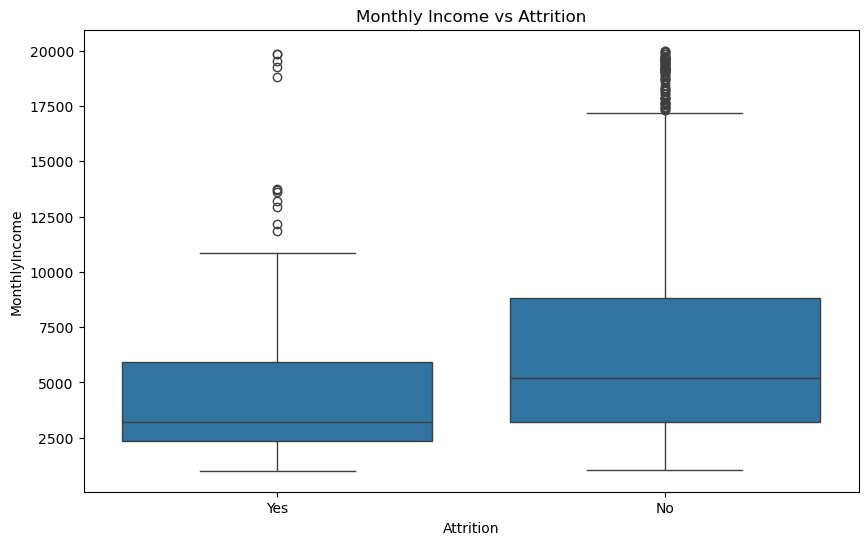

In [6]:
plt.figure(figsize=(10,6)) 
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

step 3:Data Preprocessing 

In [7]:

df.drop(columns=["EmployeeNumber","EmployeeCount","Over18","StandardHours"], inplace=True)
df.shape

(1470, 31)

In [8]:
encoders={}
for col in df.select_dtypes(include=["object"]).columns:
    lb = LabelEncoder()
    df[col]= lb.fit_transform(df[col])
    encoders[col] = lb
    X = df.drop("Attrition",axis=1)
    y=df["Attrition"]
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

Step 4: Modeling  and Tunning(Hyperameter)

In [9]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    "n_estimators":[50,100],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}
#gridSearchCV is conputationally expensive,so we well use a smaller grid for
grid_search = GridSearchCV(rf,param_grid=param_grid,cv=5,scoring="f1")
grid_search.fit(X_train,y_train)
print("Best parameters:",grid_search.best_params_)

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


In [12]:
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)
print(classification_report(y_test,predictions))
print(confusion_matrix(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.71      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.80      0.56      0.58       294
weighted avg       0.86      0.88      0.84       294

[[253   2]
 [ 34   5]]


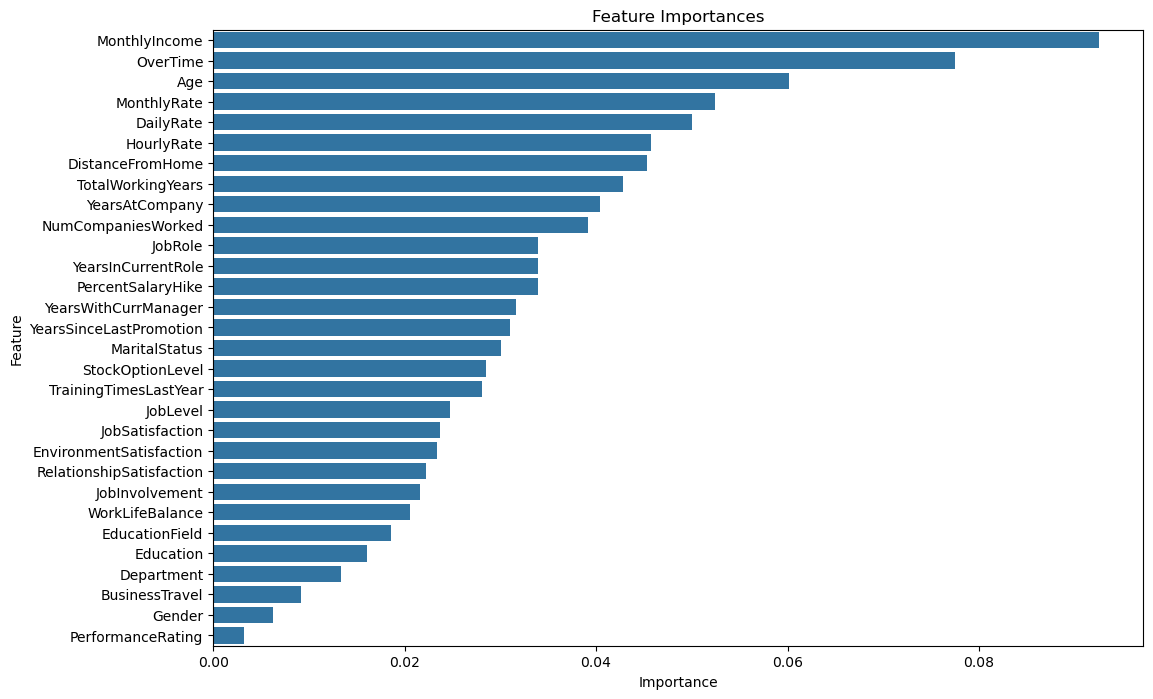

In [14]:
importances = pd.DataFrame({
    "Feature":X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance",ascending=False)
plt.figure(figsize=(12,8))
sns.barplot(x="Importance",y="Feature",data=importances)
plt.title("Feature Importances")
plt.show()

In [15]:
model = RandomForestClassifier(n_estimators=50, max_depth=20,min_samples_split=5,min_samples_leaf=1,random_state=42)
#model = RandomForestClassifier
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=50,
                       random_state=42)

In [17]:
joblib.dump(model,"model_attrition.pkl")
joblib.dump(encoders,"attrition_encoder.pkl")
joblib.dump(X.columns.to_list(),"feature_columns.pkl")

['feature_columns.pkl']